<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Quantum_wave_dynamic_Blochs_Theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Wave Dynamics: Bloch's Theorem in Periodic Potentials

## Overview
This notebook provides a high-fidelity simulation of an electron wave packet propagating through various two-dimensional crystal lattices. The objective is to visualize the principles of **Bloch's Theorem** and the **Nearly-Free Electron (NFE) Model**, which are fundamental to the modern band theory of solids.

## Theoretical Background

### 1. The Schrödinger Equation
The dynamics of the electron are governed by the Time-Dependent Schrödinger Equation (TDSE):

$$i\hbar \frac{\partial}{\partial t} \Psi(\mathbf{r}, t) = \left[ -\frac{\hbar^2}{2m} \nabla^2 + V(\mathbf{r}) \right] \Psi(\mathbf{r}, t)$$

In this simulation, we solve this equation in two dimensions ($x, y$) using the Split-Step Fourier Method (SSFM).

### 2. Bloch's Theorem
Bloch's Theorem states that for a particle moving in a periodic potential $V(\mathbf{r} + 	ext{R}) = V(\mathbf{r})$, where $\text{R}$ is a lattice vector, the eigenstates of the Hamiltonian take the form:

$$\Psi_{n\mathbf{k}}(\mathbf{r}) = e^{i\mathbf{k} \cdot \mathbf{r}} u_{n\mathbf{k}}(\mathbf{r})$$

where $u_{n\mathbf{k}}(\mathbf{r})$ is a function with the same periodicity as the lattice. This visualization demonstrates how a delocalized wave packet interacts with periodic symmetries to form these modulated structures.

### 3. Nearly-Free Electron Model
The simulation utilizes a 'Pseudopotential' approach within the Nearly-Free Electron regime. Instead of deep, divergent Coulombic wells, we use smooth Gaussian attractive potentials. This allows for the observation of:
*   **Diffraction**: The splitting and interference of the wave function as it encounters the lattice.
*   **Concentration**: The increase in probability density at lattice sites (potential minima) due to constructive interference and energetic preference.
*   **Symmetry Effects**: Variations in wave propagation through Square, Hexagonal, Rectangular, and Defected (Diamond with vacancy) lattices.

## Numerical Implementation

### Split-Step Fourier Method (SSFM)
The SSFM evolves the wave function by alternating between real space (to apply the potential operator) and momentum space (to apply the kinetic operator). This method is unconditionally stable and exhibits spectral convergence for the spatial derivatives.

1.  **Potential Step**: $\Psi' = e^{-i V \Delta t / 2\hbar} \Psi$
2.  **Kinetic Step**: $\Phi = \mathcal{F}\{\Psi'\}$, then $\Phi' = e^{-i \hbar k^2 \Delta t / 2m} \Phi$
3.  **Inverse Fourier Step**: $\Psi'' = \mathcal{F}^{-1}\{\Phi'\}$
4.  **Final Potential Step**: $\Psi_{t+\Delta t} = e^{-i V \Delta t / 2\hbar} \Psi''$

## References

*   Ashcroft, N. W., & Mermin, N. D. (1976). *Solid State Physics*. Saunders College.
*   Kittel, C. (2004). *Introduction to Solid State Physics*. Wiley.
*   Feit, M. D., Fleck, J. A., & Steiger, A. (1982). *Solution of the Schrödinger equation by a spectral method*. Journal of Computational Physics, 47(3), 412-433.
*   Tannor, D. J. (2007). *Introduction to Quantum Mechanics: A Time-Dependent Perspective*. University Science Books.

In [18]:
"""
Bloch's Theorem: Nearly-Free Electron Wave Packet Propagation
============================================================
Author: Mugambi Ndwiga (@craftsandengineering)

This script simulates the 2D Time-Dependent Schrödinger Equation (TDSE) for an
electron wave packet traveling through various periodic potentials (lattices).
It demonstrates Bloch's Theorem and the Nearly-Free Electron model using the
Split-Step Fourier Method (SSFM).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from scipy.fftpack import fft2, ifft2
from IPython.display import Video, display

# --- Simulation & Grid Parameters ---
N = 256                # Number of grid points (2^n for efficient FFT)
L = 20.0               # Domain size in atomic units
x_grid = np.linspace(-L/2, L/2, N)
y_grid = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x_grid, y_grid)
dx = x_grid[1] - x_grid[0]

# --- Momentum Space (Fourier Space) Setup ---
# k_vec represents the crystal momentum coordinates
k_vec = 2 * np.pi * np.fft.fftfreq(N, d=dx)
Kx, Ky = np.meshgrid(k_vec, k_vec)

# --- Animation Metadata ---
FPS = 30
DURATION_SEC = 35
TOTAL_FRAMES = DURATION_SEC * FPS
LATTICE_TYPES = ['Square', 'Hexagonal', 'Rectangular', 'Diamond (Vacancy)']
FRAMES_PER_LATTICE = TOTAL_FRAMES // len(LATTICE_TYPES)

# --- Physics Constants ---
dt = 0.004             # Time step (must be small enough for SSFM stability)
kx_packet = 12.0       # Initial group velocity (momentum) in the x-direction

def get_potential(type_name):
    """
    Generates the potential energy landscape V(x, y) for different lattice geometries.

    Args:
        type_name (str): The name of the lattice geometry to generate.
    Returns:
        tuple: (V, nodes) where V is the 2D potential array and nodes is a list of atom coordinates.
    """
    V = np.zeros((N, N))
    # v0: Potential depth (negative for attraction)
    # sigma: Width of the Gaussian representing the atomic potential
    v0, sigma = -8.0, 0.55
    nodes = []

    # Define atomic positions based on lattice symmetry
    if type_name == 'Square':
        for i in np.arange(-7, 8, 2.5):
            for j in np.arange(-7, 8, 2.5): nodes.append((i, j))
    elif type_name == 'Hexagonal':
        s = 2.8
        for i in range(-4, 5):
            for j in range(-4, 5): nodes.append((i*s + (j%2)*(s/2), j*s*(np.sqrt(3)/2)))
    elif type_name == 'Rectangular':
        for i in np.arange(-8, 9, 4.0):
            for j in np.arange(-6, 7, 2.0): nodes.append((i, j))
    elif type_name == 'Diamond (Vacancy)':
        s = 2.5
        for i in np.arange(-7.5, 8, s):
            for j in np.arange(-7.5, 8, s):
                # Create a vacancy by skipping the central atom
                if not (abs(i) < 0.5 and abs(j) < 0.5): nodes.append((i, j))

    # Sum up individual Gaussian potentials to create the periodic potential
    for nx, ny in nodes:
        V += v0 * np.exp(-((X-nx)**2 + (Y-ny)**2) / (2 * sigma**2))
    return V, nodes

def get_initial_psi():
    """
    Creates a Gaussian wave packet injected from the left side of the domain.

    The packet width (sigma_w) is chosen to be large relative to the lattice
    spacing to represent a delocalized Bloch state.
    """
    x0, y0 = -9.0, 0.0   # Starting position
    sigma_w = 2.2        # Spatial spread of the packet
    # Wave function: Gaussian spatial envelope * Plane wave phase factor
    psi = np.exp(-((X-x0)**2 + (Y-y0)**2) / (4 * sigma_w**2)) * np.exp(1j * (kx_packet*X))
    # Normalize the wave function such that the integral of |psi|^2 = 1
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx**2)

# Pre-calculate the Kinetic operator in Fourier space: exp(-i * K^2 * dt / 2)
K_op = np.exp(-0.5j * (Kx**2 + Ky**2) * dt)

# --- Visualization Setup ---
fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
plt.subplots_adjust(left=0, bottom=0, right=1, top=1)

FILENAME = 'bloch_annotated.mp4'
writer = FFMpegWriter(fps=FPS, metadata=dict(title="Bloch Dynamics", artist='Mugambi Ndwiga'))

# --- Simulation Loop ---
with writer.saving(fig, FILENAME, dpi=120):
    current_lattice_idx = -1
    for i in range(TOTAL_FRAMES):
        idx = min(i // FRAMES_PER_LATTICE, len(LATTICE_TYPES) - 1)

        # Reset the simulation for each new lattice type
        if idx != current_lattice_idx:
            current_lattice_idx = idx
            V, nodes = get_potential(LATTICE_TYPES[idx])
            # Pre-calculate the Potential operator: exp(-i * V * dt / 2)
            V_op = np.exp(-0.5j * V * dt)
            psi = get_initial_psi()

        # --- Split-Step Fourier Method Step ---
        # 1. Half-step in Real Space (Potential Energy)
        psi = V_op * psi
        # 2. Full-step in Fourier Space (Kinetic Energy)
        psi = ifft2(K_op * fft2(psi))
        # 3. Half-step in Real Space (Potential Energy)
        psi = V_op * psi

        # --- Rendering ---
        ax.clear()
        ax.set_facecolor('black')
        prob = np.abs(psi)**2  # Probability Density

        # Use 'magma' colormap for high contrast; normalization highlights diffraction
        ax.imshow(prob, extent=[-L/2, L/2, -L/2, L/2], origin='lower', cmap='magma',
                  vmin=0, vmax=np.max(prob)*0.7, interpolation='bicubic')

        # Plot lattice nodes as glowing cyan dots
        nx_p, ny_p = zip(*nodes)
        ax.scatter(nx_p, ny_p, c='#00FFFF', s=12, alpha=0.3, edgecolors='none')

        # Overlay Educational Text
        ax.text(0, 9.2, "Quantum Wave Dynamics: Bloch's Theorem",
                color='white', fontsize=16, weight='bold', ha='center', alpha=0.8)
        ax.text(0, 8.4, f"Current Lattice: {LATTICE_TYPES[idx]}",
                color='cyan', fontsize=12, weight='light', ha='center', alpha=0.6)

        # Physics Annotation regarding peak concentration
        ax.text(0, -8.8, "Observation: Wave function peaks concentrate on lattice nodes due to potential minima attraction.",
                color='white', fontsize=9, style='italic', ha='center', alpha=0.5)

        # Branding Watermark
        ax.text(9.5, -9.5, "@craftsandengineering", color='white', alpha=0.15, ha='right', fontsize=9)

        ax.axis('off')
        writer.grab_frame()

plt.close()
display(Video(FILENAME, embed=True))

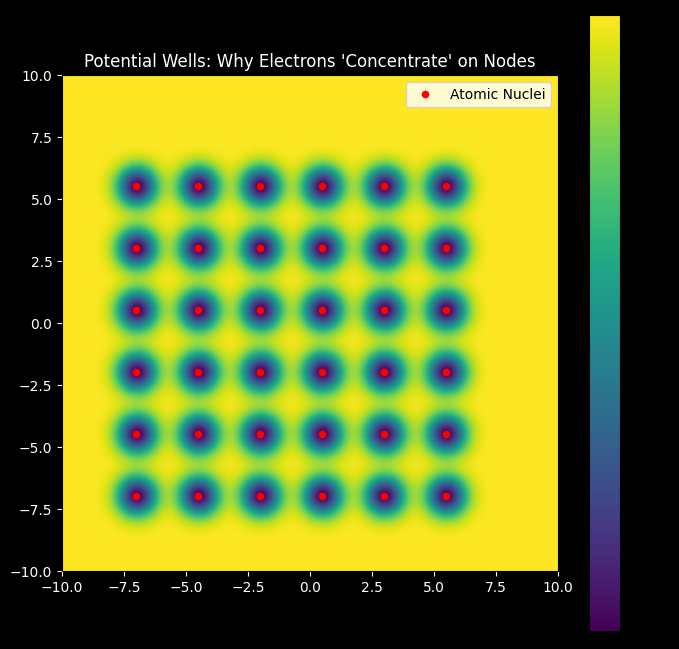

The purple/dark spots are the 'traps' (potential minima) where the wave function peaks concentrate.


In [15]:
import matplotlib.pyplot as plt

# Visualize the Potential Energy Landscape (The 'Wells')
V_square, nodes_square = get_potential('Square')

fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
im = ax.imshow(V_square, extent=[-L/2, L/2, -L/2, L/2], cmap='viridis', origin='lower')
plt.colorbar(im, label='Potential Energy V(x,y)')
ax.set_title("Potential Wells: Why Electrons 'Concentrate' on Nodes", color='white')
ax.set_facecolor('black')
ax.tick_params(colors='white')

# Overlap the nodes
nx_p, ny_p = zip(*nodes_square)
ax.scatter(nx_p, ny_p, c='red', s=20, label='Atomic Nuclei')
plt.legend()
plt.show()

print("The purple/dark spots are the 'traps' (potential minima) where the wave function peaks concentrate.")